   userId  movieId  rating   timestamp  \
0       1       16     4.0  1217897793   
1       1       24     1.5  1217895807   
2       1       32     4.0  1217896246   
3       1       47     4.0  1217896556   
4       1       50     4.0  1217896523   

                                       title                   genres  
0                              Casino (1995)              Crime|Drama  
1                              Powder (1995)             Drama|Sci-Fi  
2  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)  Mystery|Sci-Fi|Thriller  
3                Seven (a.k.a. Se7en) (1995)         Mystery|Thriller  
4                 Usual Suspects, The (1995)   Crime|Mystery|Thriller  
RMSE: 0.7387907071918868
MAE: 0.5168094487979743

Top Recommendations for User 1:
   movieId                                   title                   genres
0     1193  One Flew Over the Cuckoo's Nest (1975)                    Drama
1     4226                          Memento (2000)         Mystery|Thriller
2    

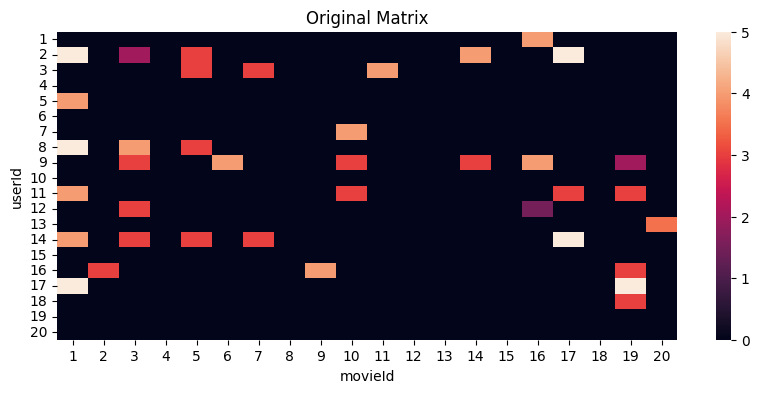

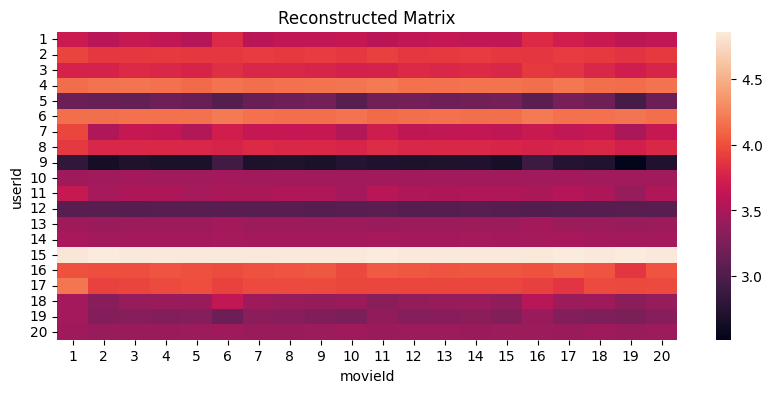

In [5]:
# ==========================================
# SCENARIO 1: MATRIX FACTORIZATION USING SVD
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==============================
# LOAD DATASETS
# ==============================

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

# Merge datasets
df = pd.merge(ratings, movies, on="movieId")

print(df.head())

# ==============================
# CREATE USER-ITEM MATRIX
# ==============================

user_item_matrix = df.pivot(index="userId", columns="movieId", values="rating")

# ==============================
# NORMALIZATION
# ==============================

user_means = user_item_matrix.mean(axis=1)
matrix_norm = user_item_matrix.sub(user_means, axis=0)
matrix_norm = matrix_norm.fillna(0)

# ==============================
# SVD
# ==============================

U, sigma, Vt = np.linalg.svd(matrix_norm, full_matrices=False)
sigma = np.diag(sigma)

# ==============================
# REDUCE DIMENSIONS
# ==============================

k = 20

U_k = U[:, :k]
sigma_k = sigma[:k, :k]
Vt_k = Vt[:k, :]

# ==============================
# RECONSTRUCTION
# ==============================

reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)
reconstructed = reconstructed + user_means.values.reshape(-1, 1)

reconstructed_df = pd.DataFrame(reconstructed,
                               index=user_item_matrix.index,
                               columns=user_item_matrix.columns)

# ==============================
# EVALUATION
# ==============================

actual = user_item_matrix.values
predicted = reconstructed_df.values

mask = ~np.isnan(actual)

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
mae = mean_absolute_error(actual[mask], predicted[mask])

print("RMSE:", rmse)
print("MAE:", mae)

# ==============================
# RECOMMENDATION (WITH NAMES)
# ==============================

def recommend_movies(user_id, n=5):
    user_row = reconstructed_df.loc[user_id]
    original = user_item_matrix.loc[user_id]

    recommendations = user_row[original.isna()].sort_values(ascending=False)

    # Convert movie IDs → Titles
    rec_movies = pd.DataFrame(recommendations.head(n)).reset_index()
    rec_movies = rec_movies.merge(movies, on="movieId")

    return rec_movies[["movieId", "title", "genres"]]

print("\nTop Recommendations for User 1:")
print(recommend_movies(1))

# ==============================
# VISUALIZATION
# ==============================

plt.figure(figsize=(10, 4))
sns.heatmap(user_item_matrix.fillna(0).iloc[:20, :20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(10, 4))
sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.title("Reconstructed Matrix")
plt.show()

RMSE: 2.4639842187622807
Precision: 1.0
Recall: 0.052083333333333336

Top Recommendations for User 1:
   movieId                                              title  \
0     4226                                     Memento (2000)   
1     2329                          American History X (1998)   
2      293  Léon: The Professional (a.k.a. The Professiona...   
3     7361       Eternal Sunshine of the Spotless Mind (2004)   
4     1200                                      Aliens (1986)   

                           genres  
0                Mystery|Thriller  
1                     Crime|Drama  
2     Action|Crime|Drama|Thriller  
3            Drama|Romance|Sci-Fi  
4  Action|Adventure|Horror|Sci-Fi  


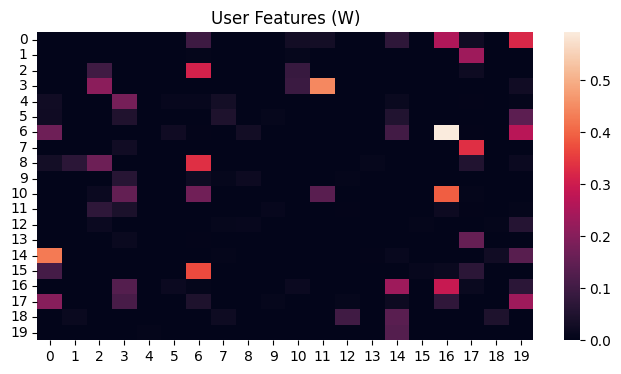

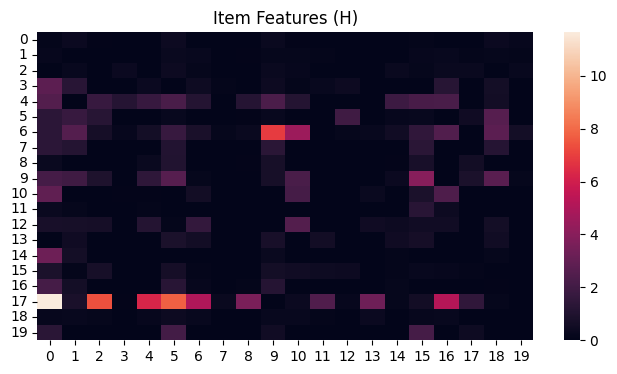

In [6]:
# ==========================================
# SCENARIO 2: MATRIX FACTORIZATION USING NMF
# ==========================================

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# ==============================
# LOAD DATASETS
# ==============================

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

df = pd.merge(ratings, movies, on="movieId")

# ==============================
# USER-ITEM MATRIX
# ==============================

user_item_matrix = df.pivot(index="userId", columns="movieId", values="rating")

matrix_filled = user_item_matrix.fillna(0)

# ==============================
# APPLY NMF
# ==============================

k = 20

nmf_model = NMF(n_components=k, init='random', random_state=42)

W = nmf_model.fit_transform(matrix_filled)
H = nmf_model.components_

# ==============================
# RECONSTRUCTION
# ==============================

reconstructed = np.dot(W, H)

reconstructed_df = pd.DataFrame(reconstructed,
                               index=user_item_matrix.index,
                               columns=user_item_matrix.columns)

# ==============================
# EVALUATION
# ==============================

actual = user_item_matrix.values
predicted = reconstructed_df.values

mask = ~np.isnan(actual)

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))
print("RMSE:", rmse)

# ==============================
# PRECISION & RECALL
# ==============================

def precision_recall_at_k(user_id, k=5, threshold=3):
    user_true = user_item_matrix.loc[user_id]
    user_pred = reconstructed_df.loc[user_id]

    relevant = user_true[user_true >= threshold].index
    top_k = user_pred.sort_values(ascending=False).head(k).index

    tp = len(set(top_k) & set(relevant))

    precision = tp / k
    recall = tp / len(relevant) if len(relevant) > 0 else 0

    return precision, recall

p, r = precision_recall_at_k(1)

print("Precision:", p)
print("Recall:", r)

# ==============================
# RECOMMENDATION (WITH NAMES)
# ==============================

def recommend_movies(user_id, n=5):
    user_row = reconstructed_df.loc[user_id]
    original = user_item_matrix.loc[user_id]

    recommendations = user_row[original.isna()].sort_values(ascending=False)

    rec_movies = pd.DataFrame(recommendations.head(n)).reset_index()
    rec_movies = rec_movies.merge(movies, on="movieId")

    return rec_movies[["movieId", "title", "genres"]]

print("\nTop Recommendations for User 1:")
print(recommend_movies(1))

# ==============================
# VISUALIZATION
# ==============================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.heatmap(W[:20, :])
plt.title("User Features (W)")
plt.show()

plt.figure(figsize=(8, 4))
sns.heatmap(H[:, :20])
plt.title("Item Features (H)")
plt.show()